###Question 1: PCA Implementation and Reconstruction Study

In [1]:
#import libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [109]:
#load dataset

digits = load_digits()
X = digits.data   # shape (n_samples, 64)

print("Original Shape:", X.shape)

Original Shape: (1797, 64)


In [110]:
# mean center
mean = np.mean(X, axis=0)
X_centered = X - mean

In [111]:
# covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (64, 64)


In [112]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh used because covariance matrix is symmetric

In [113]:
#sort eigen values in descending
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

In [114]:
# variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

In [115]:
M_values = [2, 5, 10, 20, 30, 40, 50, 64]

reconstruction_errors = []
explained_variances = []

In [116]:
for M in M_values:
    # Select top M eigenvectors
    W = eigenvectors[:, :M]

    # Project data
    Z = np.dot(X_centered, W)

    # Reconstruct data
    X_reconstructed = np.dot(Z, W.T) + mean

    # Reconstruction error MSE
    error = np.mean((X - X_reconstructed) ** 2)

    reconstruction_errors.append(error)
    explained_variances.append(np.sum(explained_variance_ratio[:M]))

    print(f"M={M} | Error={error:.4f} | Explained Var={explained_variances[-1]:.4f}")

M=2 | Error=13.4210 | Explained Var=0.2851
M=5 | Error=8.5424 | Explained Var=0.5450
M=10 | Error=4.9143 | Explained Var=0.7382
M=20 | Error=1.9843 | Explained Var=0.8943
M=30 | Error=0.7681 | Explained Var=0.9591
M=40 | Error=0.2215 | Explained Var=0.9882
M=50 | Error=0.0085 | Explained Var=0.9995
M=64 | Error=0.0000 | Explained Var=1.0000


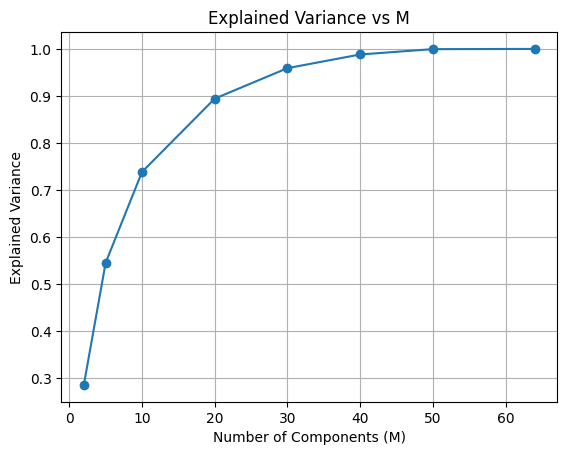

In [117]:
#plot - Explained Variance vs M
plt.figure()
plt.plot(M_values, explained_variances, marker='o')
plt.xlabel("Number of Components (M)")
plt.ylabel("Explained Variance")
plt.title("Explained Variance vs M")
plt.grid()
plt.show()


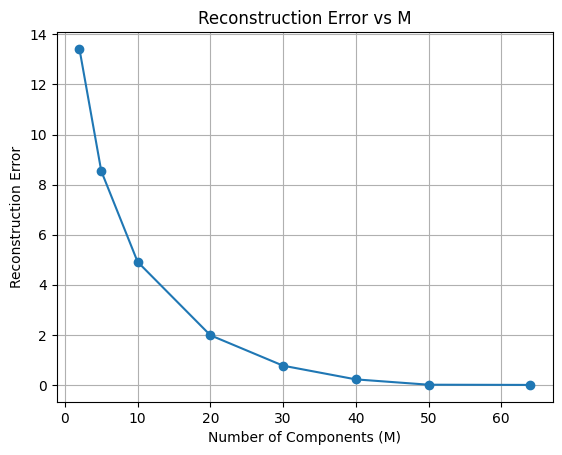

In [118]:
#Plot - Reconstruction Error vs M
plt.figure()
plt.plot(M_values, reconstruction_errors, marker='o')
plt.xlabel("Number of Components (M)")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs M")
plt.grid()
plt.show()

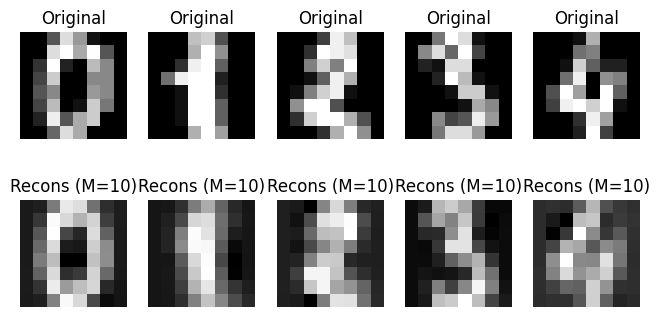

In [119]:
#original vs reconstructed images
M = 10

W = eigenvectors[:, :M]
Z = np.dot(X_centered, W)
X_reconstructed = np.dot(Z, W.T) + mean

plt.figure(figsize=(8,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(8,8), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(X_reconstructed[i].reshape(8,8), cmap='gray')
    plt.title(f"Recons (M={M})")
    plt.axis('off')

plt.show()

### Question 2: PCA using SVD and Comparison

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits

In [121]:
digits = load_digits()
X = digits.data

# Center data
mean = np.mean(X, axis=0)
X_centered = X - mean

print("Shape:", X.shape)

Shape: (1797, 64)


In [122]:
#perform SVD - PCA USING SVD
start_svd = time.time()

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

end_svd = time.time()
svd_time = end_svd - start_svd

print("SVD done. Time:", svd_time)

SVD done. Time: 0.014530658721923828


In [123]:
V = Vt.T   # principal components

In [124]:
n_samples = X.shape[0]

eigenvalues_svd = (S**2) / (n_samples - 1)

explained_variance_ratio_svd = eigenvalues_svd / np.sum(eigenvalues_svd)

In [125]:
#PCA USING EIGEN

start_eig = time.time()

cov_matrix = np.cov(X_centered, rowvar=False)
eigenvalues_eig, eigenvectors_eig = np.linalg.eigh(cov_matrix)

# Sort
idx = np.argsort(eigenvalues_eig)[::-1]
eigenvalues_eig = eigenvalues_eig[idx]
eigenvectors_eig = eigenvectors_eig[:, idx]

end_eig = time.time()
eig_time = end_eig - start_eig

print("Eigen PCA done. Time:", eig_time)

Eigen PCA done. Time: 0.007257223129272461


In [126]:
M_values = [2, 5, 10, 20, 30, 40, 50, 64]

error_svd = []
error_eig = []

In [127]:
#Projection and Reconstruction
for M in M_values:

    # SVD PCA
    W_svd = V[:, :M]
    Z_svd = np.dot(X_centered, W_svd)
    X_rec_svd = np.dot(Z_svd, W_svd.T) + mean
    err_svd = np.mean((X - X_rec_svd)**2)
    error_svd.append(err_svd)

    #Eigen PCA
    W_eig = eigenvectors_eig[:, :M]
    Z_eig = np.dot(X_centered, W_eig)
    X_rec_eig = np.dot(Z_eig, W_eig.T) + mean
    err_eig = np.mean((X - X_rec_eig)**2)
    error_eig.append(err_eig)

    print(f"M={M} | SVD Err={err_svd:.4f} | Eigen Err={err_eig:.4f}")

M=2 | SVD Err=13.4210 | Eigen Err=13.4210
M=5 | SVD Err=8.5424 | Eigen Err=8.5424
M=10 | SVD Err=4.9143 | Eigen Err=4.9143
M=20 | SVD Err=1.9843 | Eigen Err=1.9843
M=30 | SVD Err=0.7681 | Eigen Err=0.7681
M=40 | SVD Err=0.2215 | Eigen Err=0.2215
M=50 | SVD Err=0.0085 | Eigen Err=0.0085
M=64 | SVD Err=0.0000 | Eigen Err=0.0000


In [128]:
print("M_values:", len(M_values))
print("error_svd:", len(error_svd))
print("error_eig:", len(error_eig))

M_values: 8
error_svd: 8
error_eig: 8


In [129]:
#Difference between eigenvalues and singular values
print("\nFirst 10 Eigenvalues (Eigen PCA):")
print(eigenvalues_eig[:10])

print("\nFirst 10 Eigenvalues (from SVD):")
print(eigenvalues_svd[:10])

diff = np.abs(eigenvalues_eig - eigenvalues_svd)

print("\nDifference (first 10):")
print(diff[:10])




First 10 Eigenvalues (Eigen PCA):
[179.0069301  163.71774688 141.78843909 101.1003752   69.51316559
  59.10852489  51.88453911  44.01510667  40.31099529  37.0117984 ]

First 10 Eigenvalues (from SVD):
[179.0069301  163.71774688 141.78843909 101.1003752   69.51316559
  59.10852489  51.88453911  44.01510667  40.31099529  37.0117984 ]

Difference (first 10):
[5.68434189e-14 1.13686838e-13 3.41060513e-13 2.27373675e-13
 0.00000000e+00 8.52651283e-14 2.84217094e-14 5.68434189e-14
 5.68434189e-14 7.10542736e-15]


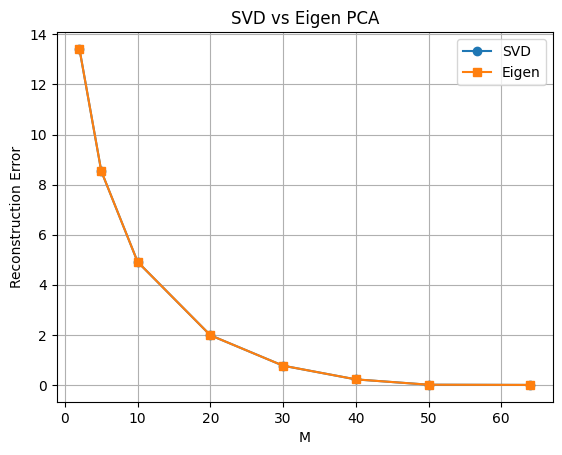

In [130]:
#Reconstruction Error Comparison
plt.figure()

plt.plot(M_values, error_svd, marker='o', label='SVD')
plt.plot(M_values, error_eig, marker='s', label='Eigen')

plt.xlabel("M")
plt.ylabel("Reconstruction Error")
plt.title("SVD vs Eigen PCA")

plt.legend()
plt.grid()
plt.show()

In [131]:
print("\nRuntime Comparison:")
print(f"SVD Time: {svd_time:.6f} sec")
print(f"Eigen Time: {eig_time:.6f} sec")


Runtime Comparison:
SVD Time: 0.014531 sec
Eigen Time: 0.007257 sec


In [ ]:
### Question 3: PCA Performance on Different Data Structures

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons

In [53]:
def pca(X, M):
    # Center data
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # Covariance
    cov = np.cov(X_centered, rowvar=False)

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Select M components
    W = eigenvectors[:, :M]

    # Project
    Z = X_centered @ W

    # Reconstruct
    X_rec = Z @ W.T + mean

    return Z, X_rec, eigenvalues

In [54]:
digits = load_digits()
X_real = digits.data

In [56]:
#apply pca 1D & 2D
Z1_real, Xrec1_real, eig_real = pca(X_real, 1)
Z2_real, Xrec2_real, _ = pca(X_real, 2)

In [57]:
#Reconstruction Error

err1_real = np.mean((X_real - Xrec1_real)**2)
err2_real = np.mean((X_real - Xrec2_real)**2)

print("Real Data Errors:")
print("1D:", err1_real)
print("2D:", err2_real)

Real Data Errors:
1D: 15.977678462234499
2D: 13.421012200761453


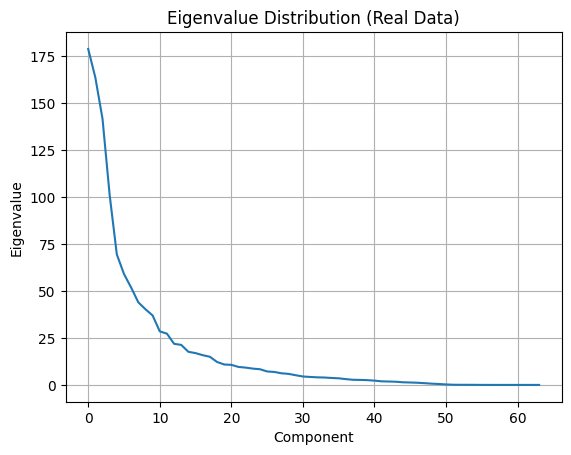

In [58]:
#Eigenvalue Distribution Plot
plt.figure()
plt.plot(eig_real)
plt.title("Eigenvalue Distribution (Real Data)")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

NONLINEAR DATASET

In [61]:
#generalize nonlinear data
X_nonlin, _ = make_moons(n_samples=500, noise=0.05)

In [62]:
#apply pca
Z1_nonlin, Xrec1_nonlin, eig_nonlin = pca(X_nonlin, 1)
Z2_nonlin, Xrec2_nonlin, _ = pca(X_nonlin, 2)

In [63]:
#Reconstruction Error
err1_nonlin = np.mean((X_nonlin - Xrec1_nonlin)**2)
err2_nonlin = np.mean((X_nonlin - Xrec2_nonlin)**2)

print("\nNonlinear Data Errors:")
print("1D:", err1_nonlin)
print("2D:", err2_nonlin)


Nonlinear Data Errors:
1D: 0.09042220548377423
2D: 3.1208007303144665e-32


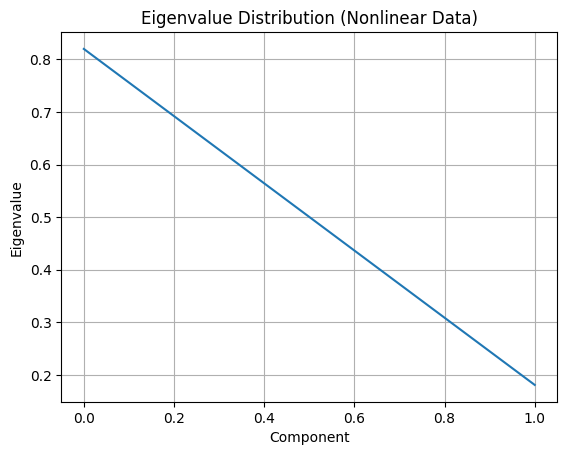

In [64]:
plt.figure()
plt.plot(eig_nonlin)
plt.title("Eigenvalue Distribution (Nonlinear Data)")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

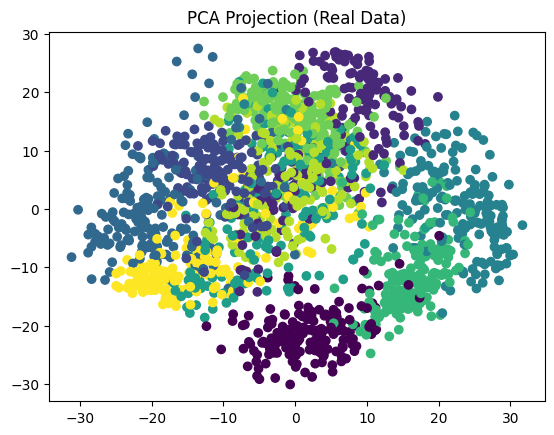

In [65]:
#Real Data Projection 2D
plt.figure()
plt.scatter(Z2_real[:,0], Z2_real[:,1], c=digits.target)
plt.title("PCA Projection (Real Data)")
plt.show()

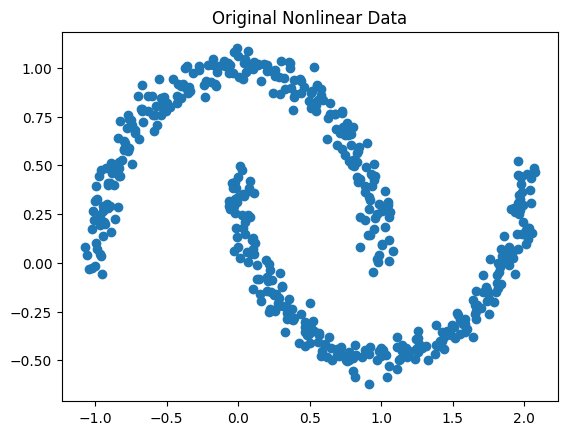

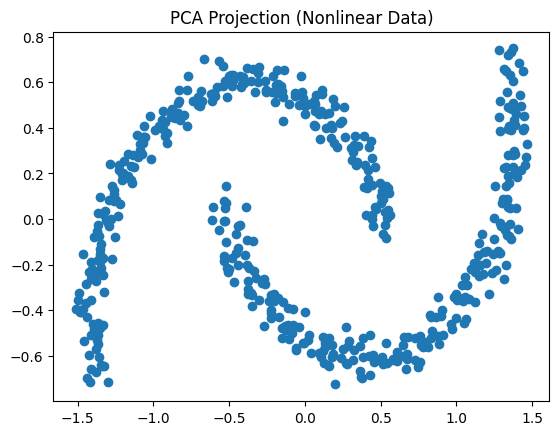

In [66]:
#Nonlinear Data Projection
plt.figure()
plt.scatter(X_nonlin[:,0], X_nonlin[:,1])
plt.title("Original Nonlinear Data")
plt.show()

plt.figure()
plt.scatter(Z2_nonlin[:,0], Z2_nonlin[:,1])
plt.title("PCA Projection (Nonlinear Data)")
plt.show()

### Question 4: Fisher Linear Discriminant (Binary Classification)

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [68]:
iris = load_iris()
X = iris.data
y = iris.target

# Take only 2 classes
mask = y < 2
X = X[mask]
y = y[mask]

print(X.shape, y.shape)

(100, 4) (100,)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [70]:
#Compute Class Means
X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

m0 = np.mean(X0, axis=0)
m1 = np.mean(X1, axis=0)

In [71]:
#Compute Within-Class Scatter Matrix
S_w = np.zeros((X.shape[1], X.shape[1]))

for x in X0:
    diff = (x - m0).reshape(-1,1)
    S_w += diff @ diff.T

for x in X1:
    diff = (x - m1).reshape(-1,1)
    S_w += diff @ diff.T

In [72]:
#Compute Projection Direction
w = np.linalg.inv(S_w) @ (m1 - m0)

In [73]:
def project(X, w):
    return X @ w

y_train_proj = project(X_train, w)
y_test_proj = project(X_test, w)

In [74]:
threshold = (np.mean(y_train_proj[y_train==0]) + np.mean(y_train_proj[y_train==1])) / 2

def predict(y_proj):
    return (y_proj > threshold).astype(int)

y_pred = predict(y_test_proj)

accuracy = np.mean(y_pred == y_test)
print("LDA Accuracy:", accuracy)

LDA Accuracy: 1.0


In [75]:
# pca for comparision
# Center
mean = np.mean(X_train, axis=0)
X_centered = X_train - mean

# Covariance
cov = np.cov(X_centered, rowvar=False)

# Eigen
eigvals, eigvecs = np.linalg.eigh(cov)
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

w_pca = eigvecs[:, 0]  # top component

In [76]:
train_pca = X_train @ w_pca
test_pca = X_test @ w_pca

threshold_pca = (np.mean(train_pca[y_train==0]) + np.mean(train_pca[y_train==1])) / 2

y_pred_pca = (test_pca > threshold_pca).astype(int)

acc_pca = np.mean(y_pred_pca == y_test)
print("PCA Accuracy:", acc_pca)

PCA Accuracy: 0.0


In [77]:
#Projection using m1-m0

w_mean = (m1 - m0)

train_mean = X_train @ w_mean
test_mean = X_test @ w_mean

threshold_mean = (np.mean(train_mean[y_train==0]) + np.mean(train_mean[y_train==1])) / 2

y_pred_mean = (test_mean > threshold_mean).astype(int)

acc_mean = np.mean(y_pred_mean == y_test)
print("Mean Direction Accuracy:", acc_mean)

Mean Direction Accuracy: 1.0


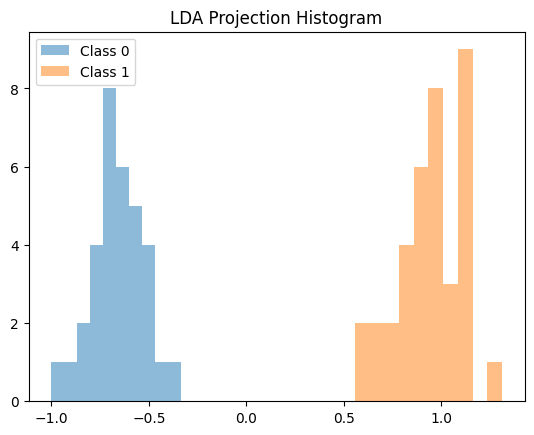

In [78]:
plt.figure()

plt.hist(y_train_proj[y_train==0], alpha=0.5, label='Class 0')
plt.hist(y_train_proj[y_train==1], alpha=0.5, label='Class 1')

plt.title("LDA Projection Histogram")
plt.legend()
plt.show()

In [79]:
mean_diff = abs(np.mean(y_train_proj[y_train==1]) - np.mean(y_train_proj[y_train==0]))
var_sum = np.var(y_train_proj[y_train==0]) + np.var(y_train_proj[y_train==1])

separation = mean_diff / var_sum

print("Separation Score (LDA):", separation)

Separation Score (LDA): 35.394968651092675


In [80]:
print("\nFinal Comparison:")
print("LDA Accuracy:", accuracy)
print("PCA Accuracy:", acc_pca)
print("Mean Direction Accuracy:", acc_mean)


Final Comparison:
LDA Accuracy: 1.0
PCA Accuracy: 0.0
Mean Direction Accuracy: 1.0


### Question 5: Multi-Class Fisher Discriminant

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [83]:
iris = load_iris()
X = iris.data
y = iris.target

print(X.shape, y.shape)

(150, 4) (150,)


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
classes = np.unique(y_train)

In [85]:
#Global Mean
mean_global = np.mean(X_train, axis=0)

In [86]:
means = {}
for c in classes:
    means[c] = np.mean(X_train[y_train == c], axis=0)

In [87]:
#Within-Class Scatter
n_features = X.shape[1]
S_w = np.zeros((n_features, n_features))

for c in classes:
    X_c = X_train[y_train == c]
    m_c = means[c]

    for x in X_c:
        diff = (x - m_c).reshape(-1,1)
        S_w += diff @ diff.T

In [89]:
#Between-Class Scatter
S_b = np.zeros((n_features, n_features))

for c in classes:
    X_c = X_train[y_train == c]
    N_c = X_c.shape[0]
    m_c = means[c].reshape(-1,1)
    m = mean_global.reshape(-1,1)

    diff = (m_c - m)
    S_b += N_c * (diff @ diff.T)

In [90]:
#generalized eigen problem

eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_w) @ S_b)

# Sort
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

In [91]:
W_lda = eigvecs[:, :2]

In [92]:
X_train_lda = X_train @ W_lda
X_test_lda = X_test @ W_lda

In [93]:
# Compute projected class means
proj_means = {}
for c in classes:
    proj_means[c] = np.mean(X_train_lda[y_train == c], axis=0)

def predict(X_proj):
    preds = []
    for x in X_proj:
        dists = [np.linalg.norm(x - proj_means[c]) for c in classes]
        preds.append(classes[np.argmin(dists)])
    return np.array(preds)

y_pred_lda = predict(X_test_lda)
acc_lda = np.mean(y_pred_lda == y_test)

print("LDA Accuracy:", acc_lda)

LDA Accuracy: 1.0


In [95]:
#PCA for comparision
# Center
mean = np.mean(X_train, axis=0)
X_centered = X_train - mean

cov = np.cov(X_centered, rowvar=False)
eigvals_pca, eigvecs_pca = np.linalg.eigh(cov)

idx = np.argsort(eigvals_pca)[::-1]
eigvecs_pca = eigvecs_pca[:, idx]

W_pca = eigvecs_pca[:, :2]

X_train_pca = X_train @ W_pca
X_test_pca = X_test @ W_pca

In [96]:
proj_means_pca = {}
for c in classes:
    proj_means_pca[c] = np.mean(X_train_pca[y_train == c], axis=0)

def predict_pca(X_proj):
    preds = []
    for x in X_proj:
        dists = [np.linalg.norm(x - proj_means_pca[c]) for c in classes]
        preds.append(classes[np.argmin(dists)])
    return np.array(preds)

y_pred_pca = predict_pca(X_test_pca)
acc_pca = np.mean(y_pred_pca == y_test)

print("PCA Accuracy:", acc_pca)

PCA Accuracy: 0.9555555555555556


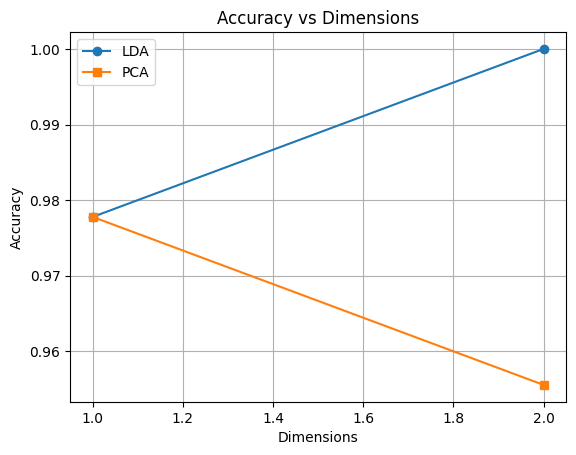

In [97]:
dims = [1, 2]
lda_accs = []
pca_accs = []

for d in dims:
    # LDA
    W = eigvecs[:, :d]
    X_tr = X_train @ W
    X_te = X_test @ W

    # Mean classifier
    means_d = {c: np.mean(X_tr[y_train==c], axis=0) for c in classes}

    preds = []
    for x in X_te:
        dists = [np.linalg.norm(x - means_d[c]) for c in classes]
        preds.append(classes[np.argmin(dists)])

    lda_accs.append(np.mean(np.array(preds) == y_test))

    # PCA
    Wp = eigvecs_pca[:, :d]
    X_trp = X_train @ Wp
    X_tep = X_test @ Wp

    means_p = {c: np.mean(X_trp[y_train==c], axis=0) for c in classes}

    preds_p = []
    for x in X_tep:
        dists = [np.linalg.norm(x - means_p[c]) for c in classes]
        preds_p.append(classes[np.argmin(dists)])

    pca_accs.append(np.mean(np.array(preds_p) == y_test))

# Plot
plt.figure()
plt.plot(dims, lda_accs, marker='o', label='LDA')
plt.plot(dims, pca_accs, marker='s', label='PCA')
plt.xlabel("Dimensions")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Dimensions")
plt.legend()
plt.grid()
plt.show()

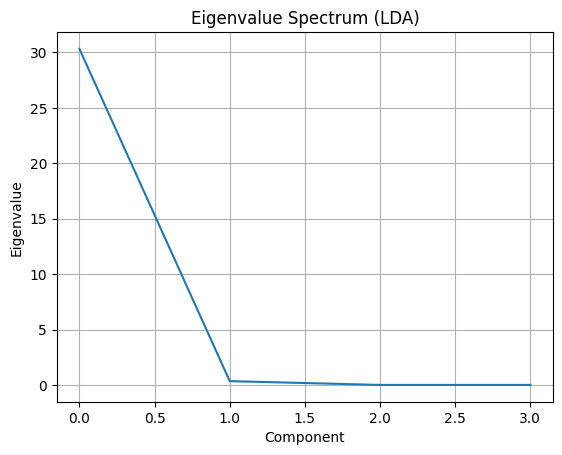

In [98]:
plt.figure()
plt.plot(np.real(eigvals))
plt.title("Eigenvalue Spectrum (LDA)")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

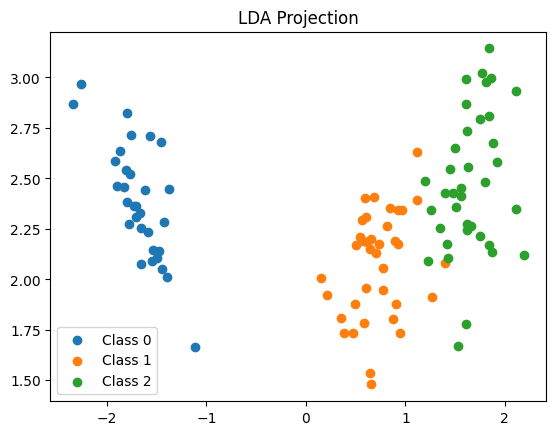

In [99]:
plt.figure()
for c in classes:
    plt.scatter(X_train_lda[y_train==c, 0], X_train_lda[y_train==c, 1], label=f"Class {c}")
plt.title("LDA Projection")
plt.legend()
plt.show()

### Q6: Agglomerative Hierarchical Clustering (Single Linkage)

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Given dataset
X = np.array([
    [1,1],
    [2,1],
    [4,3],
    [5,4],
    [3,2]
])

In [102]:
n = len(X)
dist_matrix = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        dist_matrix[i,j] = np.linalg.norm(X[i] - X[j])

print("Distance Matrix:\n", np.round(dist_matrix,2))

Distance Matrix:
 [[0.   1.   3.61 5.   2.24]
 [1.   0.   2.83 4.24 1.41]
 [3.61 2.83 0.   1.41 1.41]
 [5.   4.24 1.41 0.   2.83]
 [2.24 1.41 1.41 2.83 0.  ]]


In [103]:
Z = linkage(X, method='single')

print("Linkage Matrix:\n", Z)

Linkage Matrix:
 [[0.         1.         1.         2.        ]
 [4.         5.         1.41421356 3.        ]
 [2.         6.         1.41421356 4.        ]
 [3.         7.         1.41421356 5.        ]]


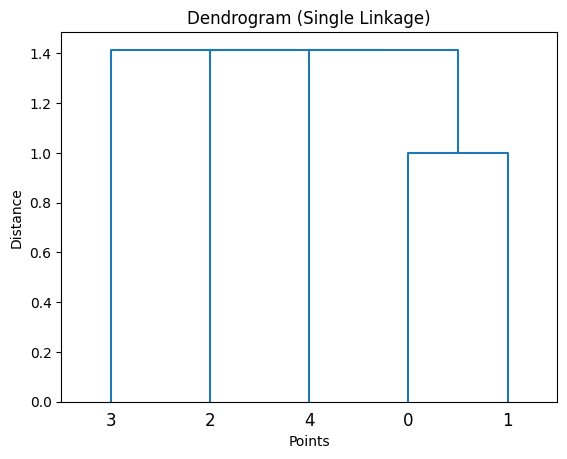

In [104]:
#dendogram
plt.figure()
dendrogram(Z)
plt.title("Dendrogram (Single Linkage)")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [105]:
clusters = fcluster(Z, t=2, criterion='distance')

print("Cluster Labels:", clusters)

Cluster Labels: [1 1 1 1 1]
